# C**ommunity detection, degree heterogeneity, and graph-tool**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install -q condacolab
import condacolab
# Workaround issue with Python 3.12:
# condacolab.install()
condacolab.install_from_url("https://github.com/conda-forge/miniforge/releases/download/25.3.1-0/Miniforge3-Linux-x86_64.sh")

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/25.3.1-0/Miniforge3-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:13
🔁 Restarting kernel...


In [3]:
!mamba install -q graph-tool

warning  libmamba [xorg-xorgproto-2024.1-hb9d3cd8_1] The following files were already present in the environment:
    - include/X11/extensions/EVI.h
    - include/X11/extensions/EVIproto.h
    - include/X11/extensions/ag.h
    - include/X11/extensions/agproto.h
    - include/X11/extensions/cup.h
    - include/X11/extensions/cupproto.h
    - include/X11/extensions/dbe.h
    - include/X11/extensions/dbeproto.h
    - include/X11/extensions/dpmsconst.h
    - include/X11/extensions/dpmsproto.h
    - include/X11/extensions/ge.h
    - include/X11/extensions/geproto.h
    - include/X11/extensions/lbx.h
    - include/X11/extensions/lbxproto.h
    - include/X11/extensions/mitmiscconst.h
    - include/X11/extensions/mitmiscproto.h
    - include/X11/extensions/multibufconst.h
    - include/X11/extensions/multibufproto.h
    - include/X11/extensions/secur.h
    - include/X11/extensions/securproto.h
    - include/X11/extensions/shapeconst.h
    - include/X11/extensions/shapeproto.h
    - include/X11

In [2]:
import graph_tool.all as gt

In [12]:
from graph_tool.all import Graph, price_network, remove_parallel_edges, remove_self_loops
try:
    from graph_tool.all import modularity as gt_modularity
except Exception:
    gt_modularity = None

from graph_tool.inference import (
    variation_information,
    mutual_information,
    reduced_mutual_information,
    partition_overlap
)

In [4]:
import math, random
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import networkx as nx
import community as community_louvain
import matplotlib.colors as mcolors

## a) Recall in `class_09`, we looked at modularity in random (i.e., \(G(n,m)\)) graphs.  Expand this result by replicating Figure 2 from  [Guimerà, R., Sales-Pardo, M., & Amaral, L.A.N. (2004). *Modularity from fluctuations in random graphs and complex networks*. *Physical Review E*, 70(2), 025101](https://arxiv.org/abs/cond-mat/0403660).  Comment on this result, especially as it relates to modularity as a measure of partition quality.

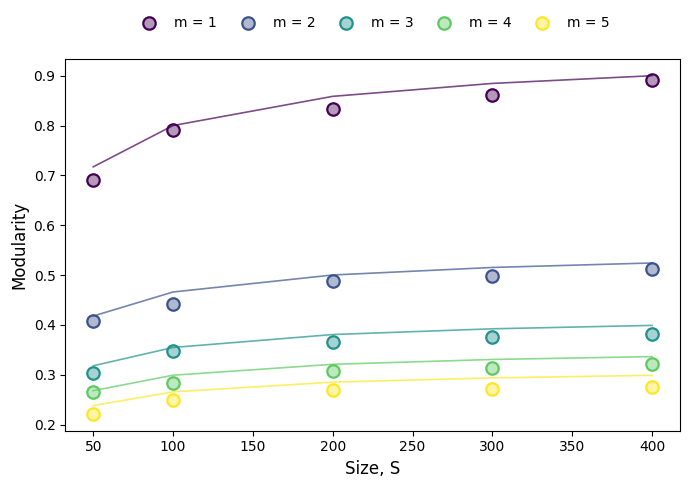

In [ ]:
def compute_modularity(G, seed=0):
    """Louvain → modularity. Converte {node: comm_id} → [set(nodes)]."""
    part = community_louvain.best_partition(G, random_state=seed)
    comms = defaultdict(set)
    for node, cid in part.items():
        comms[cid].add(node)
    return nx.community.modularity(G, list(comms.values()))

# ==== Parametri ====
sizes = [50, 100, 200, 300, 400]
m_values = [1, 2, 3, 4, 5]
a = 0.165
reps = 5

# ==== Colormap ====
cmap = plt.cm.viridis
norm = mcolors.Normalize(vmin=min(m_values), vmax=max(m_values))

plt.figure(figsize=(7,5))

for m in m_values:
    base_color = cmap(norm(m))          # colore principale (più scuro)
    light_color = mcolors.to_rgba(base_color, alpha=0.4)  # versione più chiara

    modularities = []
    for S in sizes:
        vals = []
        for r in range(reps):
            G = nx.barabasi_albert_graph(S, m, seed=10_000 + 97*S + r)
            vals.append(compute_modularity(G, seed=1234 + r))
        modularities.append(np.mean(vals))

    # --- Dati empirici: dot chiaro con bordo scuro ---
    plt.scatter(
        sizes, modularities,
        facecolors=light_color,
        edgecolors=base_color,
        s=80, linewidths=1.6,
        label=f"m = {m}",
        zorder=3
    )

    # --- Linea teorica Eq. (21): stesso colore, ma più trasparente ---
    M_theory = [(a + (1 - a)/m) * (1 - 2/np.sqrt(S)) for S in sizes]
    plt.plot(
        sizes, M_theory,
        color=base_color, linestyle='-', linewidth=1.2, alpha=0.7, zorder=2
    )

plt.xlabel("Size, S", fontsize=12)
plt.ylabel("Modularity", fontsize=12)

# === Legenda in una sola riga ===
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=len(m_values),
    frameon=False,
    handletextpad=0.8,
    columnspacing=1.2
)

plt.tight_layout()
plt.show()

## b) Now, using `graph-tool`, fit a degree-corrected and non-degree-corrected stochastic block model to the largest connected component of the `polblogs` dataset, and enforce that the resulting partitions only contain two blocks. Visualize the graph (twice) with the two different partitions.  


### **CODE FOR VISUALIZATION OF THE NETWORK**

In [5]:
SHOW_INLINE = True   # keep True for Colab display
IMG_SIZE    = 1800   # increase for more detail (e.g., 2800–4000)

# 1) Load dataset
g = gt.collection.data["polblogs"]

# 2) Party colors (RGBA)
BLUE = (0.08, 0.20, 1.00, 0.95)  # vivid blue
RED  = (1.00, 0.10, 0.10, 0.95)  # vivid red
ORANGE = (1.00, 0.50, 0.00, 0.18)
PURPLE = (0.65, 0.25, 0.95, 0.18)
BLUE_FAINT = (0.20, 0.35, 1.00, 0.08)
RED_FAINT  = (1.00, 0.25, 0.25, 0.08)

val = g.vp.value

# Node colors by party (solid lobes)
vcolor = g.new_vertex_property("vector<double>")
for v in g.vertices():
    vcolor[v] = RED if int(val[v]) == 1 else BLUE
g.vp.vcolor = vcolor

# Edge colors and widths
ecolor = g.new_edge_property("vector<double>")
ewidth = g.new_edge_property("double")
for e in g.edges():
    s = int(val[e.source()])
    t = int(val[e.target()])
    if s == 0 and t == 1:   # liberal -> conservative
        ecolor[e] = ORANGE
        ewidth[e] = 0.35
    elif s == 1 and t == 0: # conservative -> liberal
        ecolor[e] = PURPLE
        ewidth[e] = 0.35
    else:
        # within-party edges use faint party color to create the "lobe" glow
        ecolor[e] = RED_FAINT if s == 1 else BLUE_FAINT
        ewidth[e] = 0.28
g.ep.ecolor = ecolor
g.ep.ewidth = ewidth

# 3) Build a simple 2-level hierarchy (root -> {reps, dems} -> blogs) for bundling
t = gt.Graph(directed=True)
for _ in g.vertices():
    t.add_vertex()
reps = t.add_vertex()
dems = t.add_vertex()
root = t.add_vertex()
t.add_edge(root, reps)
t.add_edge(root, dems)

for tv in t.vertices():
    i = int(t.vertex_index[tv])
    if i < g.num_vertices():
        if int(val[g.vertex(i)]) == 1:
            t.add_edge(reps, tv)
        else:
            t.add_edge(dems, tv)

# 4) Radial tree layout + control points for bundled curves
tpos = gt.radial_tree_layout(t, root, weighted=True)

# Optional: rotate layout so Dems are on top and Reps on bottom
def rotate_positions(pmap, theta):
    c, s = math.cos(theta), math.sin(theta)
    for v in pmap.get_graph().vertices():
        x, y = float(pmap[v][0]), float(pmap[v][1])
        pmap[v] = (c*x - s*y, s*x + c*y)
rotate_positions(tpos, theta=math.pi/2)  # quarter turn

# Compute control points following the hierarchy
cts = gt.get_hierarchy_control_points(g, t, tpos)

# Copy positions to original graph (nodes lie on the circle)
pos = g.own_property(tpos)

# 5) Draw inline (no labels; tiny nodes; black background)
gt.graph_draw(
    g,
    pos=pos,
    bg_color=[0, 0, 0, 1],
    output_size=[IMG_SIZE, IMG_SIZE],
    inline=SHOW_INLINE,
    vertex_size=1.2,                          # hair-thin
    vertex_fill_color=g.vp.vcolor,
    vertex_color=g.vp.vcolor,
    vertex_pen_width=0.0,
    edge_control_points=cts,
    edge_color=g.ep.ecolor,
    edge_pen_width=g.ep.ewidth,
    edge_marker_size=0.0,                     # no arrowheads
    # no labels for the mask-like look
    vertex_text=None,
    output= "/content/drive/MyDrive/graph-tool/polblogs.png"
)

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7d2af8930f50, at 0x7d2afe14f470>

In [19]:
# -----------------------------
# 1. Load the polblogs network
# -----------------------------
g = gt.collection.ns["polblogs"]   # or gt.collections.ns["polblogs"]

print(f"Original graph: {g.num_vertices()} nodes, {g.num_edges()} edges")

# ------------------------------------------------------
# 2. Extract the largest connected component (undirected)
# ------------------------------------------------------
g_lcc = gt.extract_largest_component(g, directed=False, prune=True)
print(f"Largest connected component: {g_lcc.num_vertices()} nodes, {g_lcc.num_edges()} edges")

# ------------------------------------------------------
# 3. Fit SBMs with and without degree correction (EXACTLY B = 2)
# ------------------------------------------------------

# Degree-corrected SBM (forced to 2 blocks)
state_dc = gt.minimize_blockmodel_dl(
    g_lcc,
    state_args=dict(deg_corr=True),
    multilevel_mcmc_args=dict(B_min=2, B_max=2)
)

# Non-degree-corrected SBM (forced to 2 blocks)
state_ndc = gt.minimize_blockmodel_dl(
    g_lcc,
    state_args=dict(deg_corr=False),
    multilevel_mcmc_args=dict(B_min=2, B_max=2)
)

print("Description length (degree-corrected):      ", state_dc.entropy())
print("Description length (non-degree-corrected): ", state_ndc.entropy())
print("Number of blocks (DC):     ", state_dc.get_nonempty_B())
print("Number of blocks (non-DC): ", state_ndc.get_nonempty_B())

# ------------------------------------------------------
# 4. Prepare colors (red / blue) for the two blocks
# ------------------------------------------------------

# Layout (same for both visualizations)
pos = gt.sfdp_layout(g_lcc)

# Block memberships as property maps
blocks_dc = state_dc.get_blocks()
blocks_ndc = state_ndc.get_blocks()

# Convert to numpy arrays of labels
b_dc  = blocks_dc.a
b_ndc = blocks_ndc.a

# Unique labels (should be 2 each, but not necessarily {0,1})
uniq_dc  = np.unique(b_dc)
uniq_ndc = np.unique(b_ndc)

print("DC unique blocks:", uniq_dc)
print("non-DC unique blocks:", uniq_ndc)

# Define red and blue colors (RGBA)
red  = [230/255,  57/255,  70/255, 1.0]   # #e63946
blue = [ 69/255, 123/255, 157/255, 1.0]   # #457b9d

# Color property for DC model
color_dc = g_lcc.new_vertex_property("vector<float>")
for v in g_lcc.vertices():
    if b_dc[int(v)] == uniq_dc[0]:
        color_dc[v] = red
    else:
        color_dc[v] = blue

# Color property for non-DC model
color_ndc = g_lcc.new_vertex_property("vector<float>")
for v in g_lcc.vertices():
    if b_ndc[int(v)] == uniq_ndc[0]:
        color_ndc[v] = red
    else:
        color_ndc[v] = blue

# ------------------------------------------------------
# 5. Visualize the graph twice with red/blue partitions
# ------------------------------------------------------

# (a) Degree-corrected partition — show inline
gt.graph_draw(
    g_lcc,
    pos=pos,
    vertex_fill_color=color_dc,
    vertex_size=8,
    edge_pen_width=0.6,
    output_size=(800, 800),
    inline=True
)

# (b) Non-degree-corrected partition — show inline
gt.graph_draw(
    g_lcc,
    pos=pos,
    vertex_fill_color=color_ndc,
    vertex_size=8,
    edge_pen_width=0.6,
    output_size=(800, 800),
    inline=True
)

Output hidden; open in https://colab.research.google.com to view.

## c) Let’s dive more into the Markov Chain Monte Carlo (MCMC) algorithm used to arrive at the partitions when fitting stochastic block models.

## i. Print the description length of the degree-corrected and non-degree-corrected models you fit in part (b).

## ii. Fit new degree-corrected and non-degree-corrected models to the largest component of the `polblogs` dataset. After initializing `BlockState` with B = 2, use a for-loop of 1,000 iterations to collect the description lengths of each model at each step using `mcmc_sweep` (with `niter=1`; during the loop  *do not enforce the number of blocks to remain 2*). Visualize both curves in a single, labeled plot and **comment on your observations**.

In [20]:
# -------------------------------
# 1. Compare description lengths
# -------------------------------
dl_dc = state_dc.entropy()
dl_ndc = state_ndc.entropy()

print(f"Description length (degree-corrected)     : {dl_dc:.3f}")
print(f"Description length (non-degree-corrected) : {dl_ndc:.3f}")

if dl_dc < dl_ndc:
    print("→ The degree-corrected SBM gives a better (shorter) description of the network.")
elif dl_dc > dl_ndc:
    print("→ The non-degree-corrected SBM gives a better (shorter) description of the network.")
else:
    print("→ Both models have the same description length.")


# ---------------------------------------------------
# 2. How different are the two partitions?  (VI / MI)
# ---------------------------------------------------
vi  = variation_information(blocks_dc, blocks_ndc)
mi  = mutual_information(blocks_dc, blocks_ndc)
rmi = reduced_mutual_information(blocks_dc, blocks_ndc)   # ~ normalized MI in [0,1]

print("\nPartition similarity between DC-SBM and SBM:")
print(f"  Variation of information (VI)        : {vi:.4f}   (0 = identical, higher = more different)")
print(f"  Mutual information (MI)              : {mi:.4f}")
print(f"  Reduced mutual information (RMI)     : {rmi:.4f}   (≈ 1 = very similar, 0 = independent)")


# -------------------------------------------------
# 3. Modularity computed directly with graph-tool
# -------------------------------------------------
def modularity_gt(g, blocks):
    """
    Compute Newman–Girvan modularity for a graph_tool graph `g`
    and a vertex property map `blocks` with integer block labels.

    Q = sum_c [ (l_c / m) - (d_c / (2m))^2 ]
    where:
        l_c = # internal edges in community c
        d_c = sum of degrees in community c
        m   = total number of edges
    """
    m = g.num_edges()
    N = g.num_vertices()

    vs   = g.get_vertices()
    deg  = g.get_out_degrees(vs)   # degree of each vertex
    b    = blocks.a                # numpy array with block labels
    B    = int(b.max()) + 1        # number of blocks

    l = np.zeros(B, dtype=float)   # internal edges per block
    d = np.zeros(B, dtype=float)   # sum of degrees per block

    # count internal edges
    for e in g.edges():
        i = int(e.source())
        j = int(e.target())
        bi = b[i]
        bj = b[j]
        if bi == bj:
            l[bi] += 1.0           # undirected: each edge counted once

    # sum degrees per block
    for i in range(N):
        d[b[i]] += deg[i]

    Q = np.sum((l / m) - (d / (2.0 * m))**2)
    return Q

Q_dc  = modularity_gt(g_lcc, blocks_dc)
Q_ndc = modularity_gt(g_lcc, blocks_ndc)

print("\nModularity of the inferred partitions:")
print(f"  Modularity (degree-corrected)        : {Q_dc:.4f}")
print(f"  Modularity (non-degree-corrected)    : {Q_ndc:.4f}")

Description length (degree-corrected)     : 63428.953
Description length (non-degree-corrected) : 83166.299
→ The degree-corrected SBM gives a better (shorter) description of the network.

Partition similarity between DC-SBM and SBM:
  Variation of information (VI)        : 1.2900   (0 = identical, higher = more different)
  Mutual information (MI)              : 0.0000
  Reduced mutual information (RMI)     : -0.0024   (≈ 1 = very similar, 0 = independent)

Modularity of the inferred partitions:
  Modularity (degree-corrected)        : 0.8073
  Modularity (non-degree-corrected)    : 0.4718


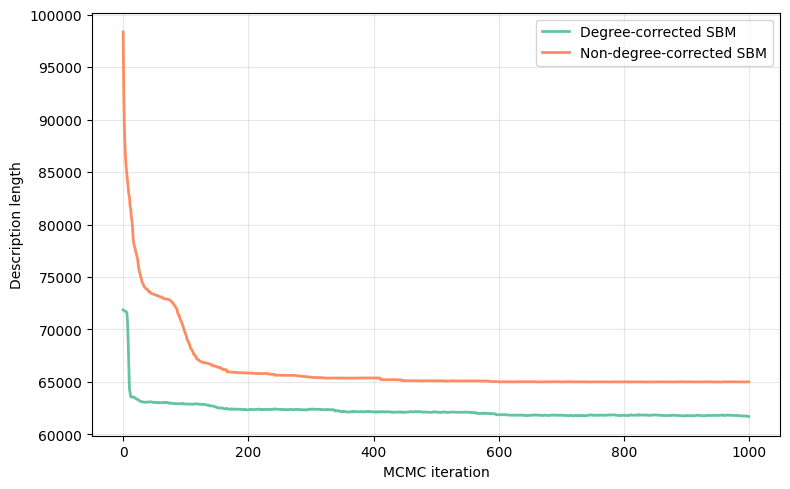

In [16]:
# ------------------------------------------------------
# Load largest connected component again (clean start)
# ------------------------------------------------------
g = gt.collection.ns["polblogs"]
g_lcc = gt.extract_largest_component(g, directed=False, prune=True)

# ------------------------------------------------------
# Initialize two BlockState objects with B = 2
# ------------------------------------------------------
state_dc = gt.BlockState(g_lcc, B=2, deg_corr=True)
state_ndc = gt.BlockState(g_lcc, B=2, deg_corr=False)

# ------------------------------------------------------
# Run 1000 MCMC sweeps and record description lengths
# ------------------------------------------------------
n_steps = 1000
dl_dc = []
dl_ndc = []

for _ in range(n_steps):
    state_dc.mcmc_sweep(niter=1)
    state_ndc.mcmc_sweep(niter=1)

    dl_dc.append(state_dc.entropy())
    dl_ndc.append(state_ndc.entropy())

# ------------------------------------------------------
# Plot the curves
# ------------------------------------------------------
plt.figure(figsize=(8, 5))

# Degree-corrected SBM curve (green)
plt.plot(
    dl_dc,
    label="Degree-corrected SBM",
    linewidth=2,
    color="#66c2a5"
)

# Non-degree-corrected SBM curve (orange)
plt.plot(
    dl_ndc,
    label="Non-degree-corrected SBM",
    linewidth=2,
    color="#fc8d62"
)

plt.xlabel("MCMC iteration")
plt.ylabel("Description length")
#plt.title("MCMC evolution of description length (polblogs)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()